# AlphaZero: Mastering Games Through Self-Play

## 1. Introduction

**AlphaZero** revolutionized game-playing AI by combining deep learning with Monte Carlo Tree Search (MCTS) to master games through pure self-play — no human knowledge required.

### What we'll learn:
- How **Monte Carlo Tree Search** explores game trees efficiently
- How a **neural network** guides search using policy and value heads
- How **self-play** generates training data
- How to combine everything into the full AlphaZero algorithm

### The Core Insight:
AlphaZero doesn't try to search the entire game tree. Instead, it uses a neural network to focus search on promising moves, then uses search results to improve the network. This **virtuous cycle** (search improves network, network improves search) leads to superhuman play.

We'll implement AlphaZero for **Tic-Tac-Toe** — simple enough to understand, complex enough to demonstrate all key concepts.

## 2. Setup

### Configuration

All hyperparameters in one place for easy experimentation.

In [ ]:
CONFIG = {
    # Reproducibility
    'seed': 42,  # Random seed for reproducibility
    
    # MCTS
    'num_simulations': 100,  # Number of MCTS simulations per move during self-play
    'num_simulations_eval': 200,  # More simulations for evaluation
    'c_puct': 1.4,  # Exploration constant for UCB formula (higher = more exploration)
    'dirichlet_alpha': 0.3,  # Dirichlet noise for exploration at root
    'dirichlet_epsilon': 0.25,  # Weight of Dirichlet noise
    'temperature': 1.0,  # Temperature for move selection (1.0 = stochastic, 0 = greedy)
    'temperature_threshold': 10,  # Switch to greedy after this many moves
    
    # Self-Play
    'num_self_play_games': 100,  # Number of games to generate per iteration
    'num_iterations': 10,  # Number of training iterations
    
    # Training
    'batch_size': 64,  # Batch size for training
    'learning_rate': 0.001,  # Learning rate for optimizer
    'max_epochs': 20,  # Max epochs per training iteration
    'early_stop_patience': 10,  # Patience for early stopping (higher = train longer)
    'l2_regularization': 1e-4,  # L2 regularization strength
    'val_split': 0.05,  # Smaller validation split for more training data
    
    # Model
    'num_residual_blocks': 3,  # Number of residual blocks
    'num_hidden': 128,  # Hidden dimension size
    
    # Evaluation
    'eval_games': 40,  # Number of games to play for evaluation
}

### Random Seed & Device

Set seed for reproducibility and detect the best available device.

In [2]:
from aiml_notebooks import get_device, set_seed

set_seed(CONFIG['seed'])
device = get_device()

print(f"Using device: {device}")

Using CUDA GPU: NVIDIA GeForce RTX 4090
Using device: cuda


## 3. Game Environment: Tic-Tac-Toe

### Why Tic-Tac-Toe?

It's the simplest game that demonstrates AlphaZero's key concepts:
- Two players take turns
- Clear win/loss/draw outcomes  
- Small enough to train quickly, complex enough to be interesting

### Game Representation

We represent the board as a 3×3 grid:
- `0` = empty
- `1` = player 1 (X)
- `-1` = player 2 (O)

We always think from **current player's perspective** by flipping the board when switching turns.

In [3]:
import numpy as np
from typing import Optional, Tuple, List

class TicTacToe:
    def __init__(self):
        self.board_size = 3
        self.action_size = 9  # 3x3 grid
        
    def get_initial_state(self) -> np.ndarray:
        """Return empty board."""
        return np.zeros((self.board_size, self.board_size), dtype=np.int8)
    
    def get_next_state(self, state: np.ndarray, action: int, player: int) -> np.ndarray:
        """Apply action and return new state."""
        row, col = action // 3, action % 3
        next_state = state.copy()
        next_state[row, col] = player
        return next_state
    
    def get_valid_moves(self, state: np.ndarray) -> np.ndarray:
        """Return binary mask of valid moves (1 = valid, 0 = invalid)."""
        return (state.reshape(-1) == 0).astype(np.uint8)
    
    def check_win(self, state: np.ndarray, player: int) -> bool:
        """Check if player has won."""
        # Check rows and columns
        for i in range(3):
            if np.all(state[i, :] == player) or np.all(state[:, i] == player):
                return True
        
        # Check diagonals
        if np.all(np.diag(state) == player) or np.all(np.diag(np.fliplr(state)) == player):
            return True
        
        return False
    
    def get_value_and_terminated(self, state: np.ndarray, player: int) -> Tuple[float, bool]:
        """Return (value, is_terminated) from current player's perspective."""
        # Check if current player won
        if self.check_win(state, player):
            return 1.0, True
        
        # Check if opponent won
        if self.check_win(state, -player):
            return -1.0, True
        
        # Check if draw (board full)
        if np.all(state != 0):
            return 0.0, True
        
        # Game continues
        return 0.0, False
    
    def get_canonical_state(self, state: np.ndarray, player: int) -> np.ndarray:
        """Return state from current player's perspective (current player is always 1)."""
        return state * player
    
    def display(self, state: np.ndarray):
        """Print board in readable format."""
        symbols = {0: '.', 1: 'X', -1: 'O'}
        for row in state:
            print(' '.join(symbols[cell] for cell in row))
        print()

# Create game instance
game = TicTacToe()
print(f"Game initialized: {game.board_size}x{game.board_size} board, {game.action_size} possible actions")

Game initialized: 3x3 board, 9 possible actions


### Test the Game

Let's play a simple game to verify our implementation works.

In [4]:
# Start a game
state = game.get_initial_state()
player = 1

print("Initial board:")
game.display(state)

# Make some moves: X(0,0), O(1,1), X(0,1), O(2,2), X(0,2) -> X wins
moves = [0, 4, 1, 8, 2]  # Convert to flat indices

for move in moves:
    state = game.get_next_state(state, move, player)
    value, terminated = game.get_value_and_terminated(state, player)
    
    print(f"Player {['O','X'][player==1]} plays position {move}:")
    game.display(state)
    
    if terminated:
        if value == 1:
            print(f"Player {['O','X'][player==1]} wins!")
        elif value == -1:
            print(f"Player {['O','X'][player==-1]} wins!")
        else:
            print("Draw!")
        break
    
    player = -player  # Switch players

Initial board:
. . .
. . .
. . .

Player X plays position 0:
X . .
. . .
. . .

Player O plays position 4:
X . .
. O .
. . .

Player X plays position 1:
X X .
. O .
. . .

Player O plays position 8:
X X .
. O .
. . O

Player X plays position 2:
X X X
. O .
. . O

Player X wins!


## 4. Monte Carlo Tree Search (MCTS) Basics

### The Core Idea

MCTS explores the game tree by **simulating many random games** and using statistics to identify promising moves.

### Four Phases (repeated many times):

1. **Selection**: Start at root, repeatedly select most promising child using UCB formula
2. **Expansion**: When reaching a leaf, add its children to the tree  
3. **Simulation**: Play out the game randomly to get an outcome
4. **Backpropagation**: Update all nodes on path with the result

### UCB Formula (Upper Confidence Bound):

$$\text{UCB}(s, a) = Q(s, a) + c_{\text{puct}} \cdot P(s, a) \cdot \frac{\sqrt{N(s)}}{1 + N(s, a)}$$

Where:
- $Q(s, a)$ = average value of taking action $a$ in state $s$ (exploitation)
- $P(s, a)$ = prior probability from neural network (AlphaZero) or uniform (vanilla MCTS)
- $N(s)$ = visit count of state $s$
- $N(s, a)$ = visit count of taking action $a$ in state $s$
- $c_{\text{puct}}$ = exploration constant (exploration)

This balances **exploitation** (choose moves with high value) and **exploration** (try moves we haven't explored much).

### Implement MCTS Node

Each node stores statistics about a state in the game tree.

In [5]:
class MCTSNode:
    def __init__(self, game: TicTacToe, state: np.ndarray, player: int, 
                 prior: float = 0.0, parent: Optional['MCTSNode'] = None):
        self.game = game
        self.state = state
        self.player = player
        self.prior = prior  # P(s,a) - prior probability from network
        self.parent = parent
        
        # Statistics
        self.visit_count = 0  # N(s)
        self.value_sum = 0.0  # Total value from all visits
        self.children = {}  # action -> MCTSNode
        
    def is_expanded(self) -> bool:
        """Check if node has children."""
        return len(self.children) > 0
    
    def get_value(self) -> float:
        """Get average value Q(s,a)."""
        if self.visit_count == 0:
            return 0.0
        return self.value_sum / self.visit_count
    
    def select_child(self, c_puct: float) -> Tuple[int, 'MCTSNode']:
        """Select child with highest UCB score."""
        best_score = -float('inf')
        best_action = None
        best_child = None
        
        for action, child in self.children.items():
            # UCB formula
            exploitation = child.get_value()
            exploration = c_puct * child.prior * np.sqrt(self.visit_count) / (1 + child.visit_count)
            score = exploitation + exploration
            
            if score > best_score:
                best_score = score
                best_action = action
                best_child = child
        
        return best_action, best_child
    
    def expand(self, policy: np.ndarray):
        """Create children for all valid moves with their prior probabilities."""
        valid_moves = self.game.get_valid_moves(self.state)
        
        for action in range(self.game.action_size):
            if valid_moves[action]:
                next_state = self.game.get_next_state(self.state, action, self.player)
                self.children[action] = MCTSNode(
                    self.game,
                    next_state,
                    -self.player,  # Switch player
                    prior=policy[action],
                    parent=self
                )
    
    def backpropagate(self, value: float):
        """Update node statistics and recurse to parent."""
        self.visit_count += 1
        self.value_sum += value
        
        # Recurse to parent (flip value since it's from opponent's perspective)
        if self.parent is not None:
            self.parent.backpropagate(-value)

print("MCTSNode class defined")

MCTSNode class defined


### Vanilla MCTS (Random Rollouts)

Let's implement basic MCTS first, using **random rollouts** for evaluation. This will help us understand the algorithm before adding neural networks.

For now, we use **uniform priors** (all moves equally likely initially).

In [6]:
class VanillaMCTS:
    def __init__(self, game: TicTacToe, num_simulations: int = 100, c_puct: float = 1.0):
        self.game = game
        self.num_simulations = num_simulations
        self.c_puct = c_puct
    
    def search(self, state: np.ndarray, player: int) -> np.ndarray:
        """Run MCTS and return action probabilities."""
        root = MCTSNode(self.game, state, player)
        
        # Expand root with uniform priors
        valid_moves = self.game.get_valid_moves(state)
        uniform_policy = valid_moves / valid_moves.sum()
        root.expand(uniform_policy)
        
        # Run simulations
        for _ in range(self.num_simulations):
            node = root
            search_path = [node]
            
            # 1. Selection - traverse tree until leaf
            while node.is_expanded():
                action, node = node.select_child(self.c_puct)
                search_path.append(node)
            
            # Check if terminal
            value, terminated = self.game.get_value_and_terminated(node.state, node.player)
            
            if not terminated:
                # 2. Expansion
                valid_moves = self.game.get_valid_moves(node.state)
                uniform_policy = valid_moves / valid_moves.sum()
                node.expand(uniform_policy)
                
                # 3. Simulation - random rollout
                value = self.rollout(node.state, node.player)
            
            # 4. Backpropagation
            for node in reversed(search_path):
                node.visit_count += 1
                node.value_sum += value
                value = -value  # Flip value for parent
        
        # Return visit count distribution as action probabilities
        action_probs = np.zeros(self.game.action_size)
        for action, child in root.children.items():
            action_probs[action] = child.visit_count
        
        if action_probs.sum() > 0:
            action_probs /= action_probs.sum()
        
        return action_probs
    
    def rollout(self, state: np.ndarray, player: int) -> float:
        """Play random game to completion and return value."""
        current_state = state.copy()
        current_player = player
        
        while True:
            value, terminated = self.game.get_value_and_terminated(current_state, current_player)
            if terminated:
                # Return value from original player's perspective
                return value if current_player == player else -value
            
            # Random move
            valid_moves = self.game.get_valid_moves(current_state)
            action = np.random.choice(np.where(valid_moves)[0])
            current_state = self.game.get_next_state(current_state, action, current_player)
            current_player = -current_player

print("VanillaMCTS class defined")

VanillaMCTS class defined


### Test Vanilla MCTS

Let's see how well random-rollout MCTS plays Tic-Tac-Toe.

In [7]:
# Create MCTS player
mcts = VanillaMCTS(game, num_simulations=50)

# Play a game with MCTS as player 1
state = game.get_initial_state()
player = 1

print("Game: MCTS (X) vs Random (O)\n")
game.display(state)

while True:
    if player == 1:
        # MCTS move
        action_probs = mcts.search(state, player)
        action = np.argmax(action_probs)
        print(f"MCTS selects position {action}")
    else:
        # Random move
        valid_moves = game.get_valid_moves(state)
        action = np.random.choice(np.where(valid_moves)[0])
        print(f"Random selects position {action}")
    
    state = game.get_next_state(state, action, player)
    game.display(state)
    
    value, terminated = game.get_value_and_terminated(state, player)
    if terminated:
        if value == 1:
            print(f"Player {['O','X'][player==1]} wins!")
        elif value == -1:
            print(f"Player {['O','X'][player==-1]} wins!")
        else:
            print("Draw!")
        break
    
    player = -player

Game: MCTS (X) vs Random (O)

. . .
. . .
. . .

MCTS selects position 6
. . .
. . .
X . .

Random selects position 1
. O .
. . .
X . .

MCTS selects position 2
. O X
. . .
X . .

Random selects position 8
. O X
. . .
X . O

MCTS selects position 0
X O X
. . .
X . O

Random selects position 5
X O X
. . O
X . O

MCTS selects position 3
X O X
X . O
X . O

Player X wins!


## 5. Neural Network (Policy + Value Heads)

### The AlphaZero Innovation

Instead of random rollouts, AlphaZero uses a **neural network** to:
1. **Policy head**: Predict which moves are promising → guides MCTS exploration
2. **Value head**: Estimate who's winning → replaces random rollouts

### Network Architecture:

```
Input (board state)
    ↓
Representation (conv layers + residual blocks)
    ↓
    ├→ Policy Head → P(a|s) for each action
    └→ Value Head → V(s) ∈ [-1, 1]
```

### Training Targets:

After each self-play game, we collect training examples:
- **Policy target**: MCTS visit count distribution (not network's original policy!)
- **Value target**: Final game outcome (1 = win, -1 = loss, 0 = draw)

This is the key insight: **MCTS improves the policy**, then we train the network to imitate the improved policy.

### Implement the Neural Network

We use PyTorch Lightning for clean, scalable training.

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import lightning as L

class ResidualBlock(nn.Module):
    def __init__(self, num_hidden: int):
        super().__init__()
        self.conv1 = nn.Conv2d(num_hidden, num_hidden, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(num_hidden)
        self.conv2 = nn.Conv2d(num_hidden, num_hidden, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(num_hidden)
        
    def forward(self, x):
        residual = x
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.bn2(self.conv2(x))
        x += residual
        x = F.relu(x)
        return x

class AlphaZeroNetwork(L.LightningModule):
    def __init__(self, 
                 game: TicTacToe,
                 num_residual_blocks: int = CONFIG['num_residual_blocks'],
                 num_hidden: int = CONFIG['num_hidden'],
                 learning_rate: float = CONFIG['learning_rate'],
                 l2_regularization: float = CONFIG['l2_regularization']):
        super().__init__()
        self.save_hyperparameters(ignore=['game'])
        self.game = game
        
        # Initial convolution
        self.start_block = nn.Sequential(
            nn.Conv2d(3, num_hidden, kernel_size=3, padding=1),  # 3 channels: player1, player2, empty
            nn.BatchNorm2d(num_hidden),
            nn.ReLU()
        )
        
        # Residual tower
        self.res_blocks = nn.ModuleList([
            ResidualBlock(num_hidden) for _ in range(num_residual_blocks)
        ])
        
        # Policy head
        self.policy_head = nn.Sequential(
            nn.Conv2d(num_hidden, 32, kernel_size=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(32 * game.board_size * game.board_size, game.action_size)
        )
        
        # Value head  
        self.value_head = nn.Sequential(
            nn.Conv2d(num_hidden, 3, kernel_size=1),
            nn.BatchNorm2d(3),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(3 * game.board_size * game.board_size, 1),
            nn.Tanh()  # Output in [-1, 1]
        )
        
    def forward(self, x):
        """Forward pass returns (policy_logits, value)."""
        x = self.start_block(x)
        
        for block in self.res_blocks:
            x = block(x)
        
        policy = self.policy_head(x)  # Logits
        value = self.value_head(x)    # [-1, 1]
        
        return policy, value
    
    def predict(self, state: np.ndarray) -> Tuple[np.ndarray, float]:
        """Predict policy and value for a single state."""
        self.eval()
        with torch.no_grad():
            # Convert state to input tensor (3 channels: player1, player2, empty)
            state_tensor = self._state_to_tensor(state).unsqueeze(0).to(self.device)
            policy_logits, value = self(state_tensor)
            
            # Apply softmax to policy
            policy = F.softmax(policy_logits, dim=1).cpu().numpy()[0]
            value = value.item()
            
        return policy, value
    
    def _state_to_tensor(self, state: np.ndarray) -> torch.Tensor:
        """Convert state to 3-channel tensor."""
        # Channel 0: current player pieces (1s)
        # Channel 1: opponent pieces (-1s become 1s)
        # Channel 2: empty squares
        tensor = torch.zeros((3, self.game.board_size, self.game.board_size))
        tensor[0] = torch.FloatTensor(state == 1)
        tensor[1] = torch.FloatTensor(state == -1)
        tensor[2] = torch.FloatTensor(state == 0)
        return tensor
    
    def training_step(self, batch, batch_idx):
        states, policy_targets, value_targets = batch
        
        # Forward pass
        policy_logits, values = self(states)
        
        # Losses
        # Use cross-entropy with soft targets (MCTS visit distribution)
        log_probs = F.log_softmax(policy_logits, dim=1)
        policy_loss = -(policy_targets * log_probs).sum(dim=1).mean()
        value_loss = F.mse_loss(values.squeeze(), value_targets)
        total_loss = policy_loss + value_loss
        
        # Logging
        self.log('train_loss', total_loss, prog_bar=True)
        self.log('train_policy_loss', policy_loss)
        self.log('train_value_loss', value_loss)
        
        return total_loss
    
    def validation_step(self, batch, batch_idx):
        states, policy_targets, value_targets = batch
        
        # Forward pass
        policy_logits, values = self(states)
        
        # Losses
        # Use cross-entropy with soft targets
        log_probs = F.log_softmax(policy_logits, dim=1)
        policy_loss = -(policy_targets * log_probs).sum(dim=1).mean()
        value_loss = F.mse_loss(values.squeeze(), value_targets)
        total_loss = policy_loss + value_loss
        
        # Logging
        self.log('val_loss', total_loss, prog_bar=True)
        self.log('val_policy_loss', policy_loss)
        self.log('val_value_loss', value_loss)
        
    def configure_optimizers(self):
        optimizer = torch.optim.Adam(
            self.parameters(),
            lr=self.hparams.learning_rate,
            weight_decay=self.hparams.l2_regularization
        )
        return optimizer

print("AlphaZeroNetwork defined")

AlphaZeroNetwork defined


### Create Network Instance

Initialize our neural network with random weights.

In [9]:
network = AlphaZeroNetwork(game).to(device)

# Count parameters
num_params = sum(p.numel() for p in network.parameters())
print(f"Network initialized with {num_params:,} parameters")

# Test prediction
state = game.get_initial_state()
policy, value = network.predict(state)

print(f"\nInitial board prediction:")
print(f"Policy shape: {policy.shape}")
print(f"Value: {value:.3f}")
print(f"Top 3 moves: {np.argsort(policy)[-3:][::-1]}")

Network initialized with 898,094 parameters

Initial board prediction:
Policy shape: (9,)
Value: -0.045
Top 3 moves: [4 3 2]


## 6. MCTS with Neural Network

### The Key Difference

Now we replace vanilla MCTS components with neural network guidance:
- **Priors**: Use network's policy instead of uniform
- **Evaluation**: Use network's value instead of random rollout

### Exploration at Root

During self-play, we add **Dirichlet noise** to the root node's priors to encourage exploration:
$$P(s, a) = (1 - \epsilon) \cdot p_a + \epsilon \cdot \eta_a$$

where $\eta \sim \text{Dir}(\alpha)$ adds randomness to prevent the agent from getting stuck.

### Implement AlphaZero MCTS

MCTS guided by neural network predictions.

In [10]:
class AlphaZeroMCTS:
    def __init__(self, game: TicTacToe, network: AlphaZeroNetwork, args: dict):
        self.game = game
        self.network = network
        self.args = args
        
    def search(self, state: np.ndarray, player: int, add_noise: bool = False) -> np.ndarray:
        """Run MCTS and return action probabilities."""
        # Get canonical state (current player is always 1)
        canonical_state = self.game.get_canonical_state(state, player)
        
        # Create root
        root = MCTSNode(self.game, canonical_state, 1)  # In canonical form, current player is 1
        
        # Get network prediction for root
        policy, _ = self.network.predict(canonical_state)
        
        # Mask invalid moves
        valid_moves = self.game.get_valid_moves(canonical_state)
        policy = policy * valid_moves
        if policy.sum() > 0:
            policy /= policy.sum()
        else:
            # All moves masked, use uniform over valid moves
            policy = valid_moves / valid_moves.sum()
        
        # Add Dirichlet noise for exploration (only during self-play)
        if add_noise:
            noise = np.random.dirichlet([self.args['dirichlet_alpha']] * self.game.action_size)
            policy = (1 - self.args['dirichlet_epsilon']) * policy + self.args['dirichlet_epsilon'] * noise
            policy = policy * valid_moves  # Re-mask
            policy /= policy.sum()
        
        # Expand root
        root.expand(policy)
        
        # Run simulations
        for _ in range(self.args['num_simulations']):
            node = root
            search_path = [node]
            
            # Selection
            while node.is_expanded():
                action, node = node.select_child(self.args['c_puct'])
                search_path.append(node)
            
            # Check terminal
            value, terminated = self.game.get_value_and_terminated(node.state, node.player)
            
            if not terminated:
                # Get network prediction
                policy, value = self.network.predict(node.state)
                
                # Mask invalid moves
                valid_moves = self.game.get_valid_moves(node.state)
                policy = policy * valid_moves
                if policy.sum() > 0:
                    policy /= policy.sum()
                else:
                    policy = valid_moves / valid_moves.sum()
                
                # Expand
                node.expand(policy)
            
            # Backpropagate
            self._backpropagate(search_path, value)
        
        # Return visit count distribution
        action_probs = np.zeros(self.game.action_size)
        for action, child in root.children.items():
            action_probs[action] = child.visit_count
        
        if action_probs.sum() > 0:
            action_probs /= action_probs.sum()
        
        return action_probs
    
    def _backpropagate(self, search_path: List[MCTSNode], value: float):
        """Backpropagate value up the search path."""
        for node in reversed(search_path):
            node.visit_count += 1
            node.value_sum += value
            value = -value  # Flip for parent

print("AlphaZeroMCTS defined")

AlphaZeroMCTS defined


## 7. Self-Play: Generating Training Data

### The Training Loop

AlphaZero improves through **self-play**:

1. Play games against itself using current network + MCTS
2. Collect training examples: `(state, MCTS_policy, game_outcome)`
3. Train network to predict MCTS policy and game outcome
4. Repeat

### Temperature-Based Move Selection

We use **temperature** to control exploration during self-play:
- Early game: $\tau = 1.0$ → stochastic sampling (explore)
- Late game: $\tau \to 0$ → greedy selection (exploit)

$$\pi(a) \propto N(s, a)^{1/\tau}$$

### Implement Self-Play

Generate one self-play game and collect training examples.

In [11]:
def play_game(game: TicTacToe, mcts: AlphaZeroMCTS, args: dict) -> List[Tuple[np.ndarray, np.ndarray, float]]:
    """Play one self-play game and return training examples."""
    train_examples = []
    
    state = game.get_initial_state()
    player = 1
    move_count = 0
    
    while True:
        move_count += 1
        
        # Get canonical state (current player is always 1)
        canonical_state = game.get_canonical_state(state, player)
        
        # Run MCTS with exploration noise
        action_probs = mcts.search(state, player, add_noise=True)
        
        # Store training example (we'll set outcome at the end)
        train_examples.append([canonical_state, action_probs, player])
        
        # Select action based on temperature
        if move_count < args['temperature_threshold']:
            # Stochastic sampling with temperature
            action = np.random.choice(len(action_probs), p=action_probs)
        else:
            # Greedy
            action = np.argmax(action_probs)
        
        # Apply action
        state = game.get_next_state(state, action, player)
        
        # Check terminal
        value, terminated = game.get_value_and_terminated(state, player)
        if terminated:
            # Assign outcomes from each player's perspective
            return_examples = []
            for hist_state, hist_probs, hist_player in train_examples:
                # Value from hist_player's perspective
                outcome = value if hist_player == player else -value
                return_examples.append((hist_state, hist_probs, outcome))
            
            return return_examples
        
        player = -player

print("play_game function defined")

play_game function defined


### Test Self-Play

Generate one game and examine the training examples.

In [12]:
# Create MCTS with neural network
alphazero_mcts = AlphaZeroMCTS(game, network, CONFIG)

# Play one game
print("Generating self-play game...")
examples = play_game(game, alphazero_mcts, CONFIG)

print(f"\nGenerated {len(examples)} training examples")
print(f"\nFirst example:")
state, policy, outcome = examples[0]
print(f"State:")
game.display(state)
print(f"Policy: {policy}")
print(f"Outcome: {outcome}")

Generating self-play game...

Generated 9 training examples

First example:
State:
. . .
. . .
. . .

Policy: [0.08 0.08 0.19 0.1  0.13 0.08 0.15 0.1  0.09]
Outcome: 1.0


## 8. Training Dataset and DataLoader

### Preparing Data for Training

We need to convert our self-play examples into PyTorch tensors for training.

In [13]:
from torch.utils.data import Dataset, DataLoader

class AlphaZeroDataset(Dataset):
    def __init__(self, examples: List[Tuple[np.ndarray, np.ndarray, float]], game: TicTacToe):
        self.examples = examples
        self.game = game
        
    def __len__(self):
        return len(self.examples)
    
    def __getitem__(self, idx):
        state, policy, value = self.examples[idx]
        
        # Convert state to 3-channel tensor
        state_tensor = torch.zeros((3, self.game.board_size, self.game.board_size))
        state_tensor[0] = torch.FloatTensor(state == 1)
        state_tensor[1] = torch.FloatTensor(state == -1)
        state_tensor[2] = torch.FloatTensor(state == 0)
        
        # Policy is a probability distribution for cross-entropy with soft targets
        policy_tensor = torch.FloatTensor(policy)
        
        # Value is a scalar
        value_tensor = torch.tensor(value, dtype=torch.float32)
        
        return state_tensor, policy_tensor, value_tensor

def create_dataloaders(examples: List[Tuple[np.ndarray, np.ndarray, float]], 
                      game: TicTacToe, 
                      batch_size: int = 64,
                      val_split: float = 0.1):
    """Create train and validation dataloaders."""
    # Shuffle and split
    np.random.shuffle(examples)
    split_idx = int(len(examples) * (1 - val_split))
    train_examples = examples[:split_idx]
    val_examples = examples[split_idx:]
    
    # Create datasets
    train_dataset = AlphaZeroDataset(train_examples, game)
    val_dataset = AlphaZeroDataset(val_examples, game)
    
    # Create dataloaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    
    return train_loader, val_loader

print("Dataset and dataloader functions defined")

Dataset and dataloader functions defined


## 9. The Full AlphaZero Training Loop

### Putting It All Together

The complete AlphaZero algorithm:

```
Initialize neural network with random weights

For each iteration:
    1. Self-Play: Generate N games using current network + MCTS
    2. Collect all training examples from these games
    3. Train network on these examples for K epochs
    4. Evaluate: Play against previous version
```

Over time, the network gets better at guiding MCTS, which produces better training data, which improves the network further.

### Implement Training Loop

Train AlphaZero through iterative self-play and learning.

In [14]:
from lightning.pytorch.loggers import CSVLogger
from lightning.pytorch.callbacks import EarlyStopping
from tqdm import tqdm

def train_alphazero(game: TicTacToe, args: dict):
    """Train AlphaZero through self-play iterations."""
    # Initialize network
    network = AlphaZeroNetwork(game).to(device)
    mcts = AlphaZeroMCTS(game, network, args)
    
    # Experience replay buffer - accumulate ALL games
    replay_buffer = []
    iteration_stats = []
    
    for iteration in range(args['num_iterations']):
        print(f"\n{'='*60}")
        print(f"Iteration {iteration + 1}/{args['num_iterations']}")
        print(f"{'='*60}")
        
        # 1. Self-Play
        print(f"\nGenerating {args['num_self_play_games']} self-play games...")
        new_examples = []
        
        for _ in tqdm(range(args['num_self_play_games']), desc="Self-play"):
            game_examples = play_game(game, mcts, args)
            new_examples.extend(game_examples)
        
        # Add to replay buffer
        replay_buffer.extend(new_examples)
        print(f"Collected {len(new_examples)} new examples")
        print(f"Replay buffer size: {len(replay_buffer)} total examples")
        
        # 2. Create dataloaders from ENTIRE replay buffer
        train_loader, val_loader = create_dataloaders(
            replay_buffer, 
            game, 
            batch_size=args['batch_size'],
            val_split=args.get('val_split', 0.1)
        )
        
        # 3. Train network
        print(f"\nTraining network on {len(replay_buffer)} examples...")
        logger = CSVLogger('logs', name=f'alphazero_iter_{iteration}')
        early_stop = EarlyStopping(
            monitor='val_loss',
            patience=args['early_stop_patience'],
            mode='min',
            verbose=False
        )
        
        trainer = L.Trainer(
            max_epochs=args['max_epochs'],
            accelerator='auto',
            devices=1,
            logger=logger,
            callbacks=[early_stop],
            enable_progress_bar=True,
            log_every_n_steps=1
        )
        
        trainer.fit(network, train_loader, val_loader)
        
        # Store stats
        iteration_stats.append({
            'iteration': iteration,
            'new_examples': len(new_examples),
            'total_examples': len(replay_buffer),
            'epochs_trained': trainer.current_epoch + 1
        })
    
    return network, iteration_stats

print("train_alphazero function defined")

train_alphazero function defined


### Run Training

Train AlphaZero! This will take several minutes.

In [15]:
# Train AlphaZero
trained_network, stats = train_alphazero(game, CONFIG)

print("\n" + "="*60)
print("Training Complete!")
print("="*60)


Iteration 1/3

Generating 100 self-play games...


Self-play: 100%|██████████| 100/100 [00:52<00:00,  1.92it/s]
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/tsilva/repos/tsilva/aiml-notebooks/.venv/lib/python3.13/site-packages/torch/__init__.py:1551: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen

Collected 843 new examples
Replay buffer size: 843 total examples

Training network on 843 examples...


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/tsilva/repos/tsilva/aiml-notebooks/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/home/tsilva/repos/tsilva/aiml-notebooks/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/home/tsilva/repos/tsilva/aiml-notebooks/.venv/lib/python3.13/site-packages/lightning/pytorch/loops/fit_loop.py:527: Found 34 module(s) in eval mode at the start of training. This may lead to unexpected behavior during training. If this is intentional, you can ignore this warning.


...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]


Training Complete!


### Visualize Training Progress

Plot loss curves from the final training iteration.

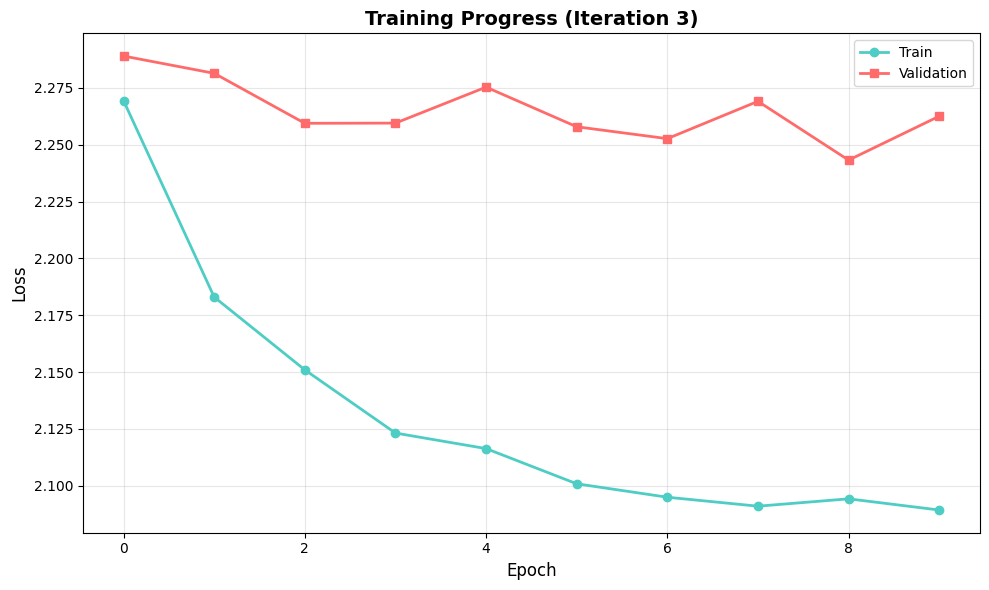


Final train loss: 2.0893
Final val loss: 2.2625


In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# Read metrics from last iteration
last_iter = CONFIG['num_iterations'] - 1
metrics_path = f'logs/alphazero_iter_{last_iter}/version_0/metrics.csv'
metrics = pd.read_csv(metrics_path)

# Separate train and val metrics
train_metrics = metrics[['epoch', 'train_loss']].dropna()
val_metrics = metrics[['epoch', 'val_loss']].dropna()

# Aggregate by epoch
train_metrics = train_metrics.groupby('epoch').mean().reset_index()
val_metrics = val_metrics.groupby('epoch').mean().reset_index()

# Plot
plt.figure(figsize=(10, 6))
plt.plot(train_metrics['epoch'], train_metrics['train_loss'], 
         label='Train', marker='o', linewidth=2, color='#4ECDC4')
plt.plot(val_metrics['epoch'], val_metrics['val_loss'],
         label='Validation', marker='s', linewidth=2, color='#FF6B6B')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title(f'Training Progress (Iteration {last_iter + 1})', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nFinal train loss: {train_metrics['train_loss'].iloc[-1]:.4f}")
print(f"Final val loss: {val_metrics['val_loss'].iloc[-1]:.4f}")

## 10. Evaluation: Watch AlphaZero Play

### Testing Our Trained Agent

Let's watch our trained AlphaZero agent play against a random player.

In [17]:
# Create MCTS with trained network (no exploration noise, more simulations)
eval_mcts = AlphaZeroMCTS(game, trained_network, {
    **CONFIG,
    'num_simulations': CONFIG['num_simulations_eval']
})

# Play a game
state = game.get_initial_state()
player = 1

print("Game: AlphaZero (X) vs Random (O)\n")
game.display(state)

while True:
    if player == 1:
        # AlphaZero move (greedy, no noise)
        action_probs = eval_mcts.search(state, player, add_noise=False)
        action = np.argmax(action_probs)
        print(f"AlphaZero selects position {action} (confidence: {action_probs[action]:.2%})")
    else:
        # Random move
        valid_moves = game.get_valid_moves(state)
        action = np.random.choice(np.where(valid_moves)[0])
        print(f"Random selects position {action}")
    
    state = game.get_next_state(state, action, player)
    game.display(state)
    
    value, terminated = game.get_value_and_terminated(state, player)
    if terminated:
        if value == 1:
            print(f"Player {['O','X'][player==1]} wins!")
        elif value == -1:
            print(f"Player {['O','X'][player==-1]} wins!")
        else:
            print("Draw!")
        break
    
    player = -player

Game: AlphaZero (X) vs Random (O)

. . .
. . .
. . .

AlphaZero selects position 5 (confidence: 33.50%)
. . .
. . X
. . .

Random selects position 8
. . .
. . X
. . O

AlphaZero selects position 1 (confidence: 49.00%)
. X .
. . X
. . O

Random selects position 3
. X .
O . X
. . O

AlphaZero selects position 6 (confidence: 34.50%)
. X .
O . X
X . O

Random selects position 7
. X .
O . X
X O O

AlphaZero selects position 0 (confidence: 45.00%)
X X .
O . X
X O O

Random selects position 2
X X O
O . X
X O O

AlphaZero selects position 4 (confidence: 100.00%)
X X O
O X X
X O O

Draw!


### Evaluate Win Rate

Play multiple games to measure AlphaZero's performance.

Evaluating: 100%|██████████| 40/40 [00:25<00:00,  1.59it/s]


Evaluation Results (40 games):
  Wins: 3 (7.5%)
  Losses: 31 (77.5%)
  Draws: 6 (15.0%)


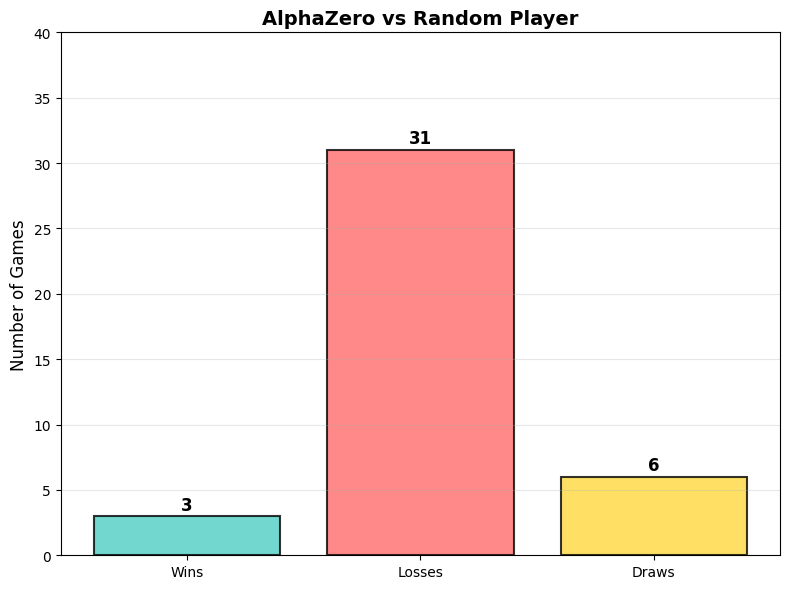

In [18]:
def evaluate_vs_random(game: TicTacToe, mcts: AlphaZeroMCTS, num_games: int = 20) -> dict:
    """Play games against random player and return statistics."""
    results = {'wins': 0, 'losses': 0, 'draws': 0}
    
    for _ in tqdm(range(num_games), desc="Evaluating"):
        state = game.get_initial_state()
        player = 1  # AlphaZero is player 1
        
        while True:
            if player == 1:
                # AlphaZero
                action_probs = mcts.search(state, player, add_noise=False)
                action = np.argmax(action_probs)
            else:
                # Random
                valid_moves = game.get_valid_moves(state)
                action = np.random.choice(np.where(valid_moves)[0])
            
            state = game.get_next_state(state, action, player)
            value, terminated = game.get_value_and_terminated(state, player)
            
            if terminated:
                if value == 1 and player == 1:  # AlphaZero wins
                    results['wins'] += 1
                elif value == 1 and player == -1:  # Random wins
                    results['losses'] += 1
                else:  # Draw
                    results['draws'] += 1
                break
            
            player = -player
    
    return results

# Evaluate
results = evaluate_vs_random(game, eval_mcts, CONFIG['eval_games'])

print(f"\nEvaluation Results ({CONFIG['eval_games']} games):")
print(f"  Wins: {results['wins']} ({results['wins']/CONFIG['eval_games']*100:.1f}%)")
print(f"  Losses: {results['losses']} ({results['losses']/CONFIG['eval_games']*100:.1f}%)")
print(f"  Draws: {results['draws']} ({results['draws']/CONFIG['eval_games']*100:.1f}%)")

# Visualize
plt.figure(figsize=(8, 6))
labels = ['Wins', 'Losses', 'Draws']
values = [results['wins'], results['losses'], results['draws']]
colors = ['#4ECDC4', '#FF6B6B', '#FFD93D']

plt.bar(labels, values, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
plt.ylabel('Number of Games', fontsize=12)
plt.title('AlphaZero vs Random Player', fontsize=14, fontweight='bold')
plt.ylim(0, CONFIG['eval_games'])

# Add value labels on bars
for i, v in enumerate(values):
    plt.text(i, v + 0.5, str(v), ha='center', fontsize=12, fontweight='bold')

plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 11. Key Takeaways

### Core Insights:

1. **AlphaZero = MCTS + Neural Network**
   - MCTS explores the game tree efficiently using statistics
   - Neural network guides search with learned intuition
   - Together they're stronger than either alone

2. **Self-Play Creates Training Data**
   - Network plays against itself to generate examples
   - MCTS improves the network's policy through search
   - Network learns to predict improved policies

3. **The Virtuous Cycle**
   - Better network → better search guidance → better training data → better network
   - This feedback loop leads to superhuman performance

4. **Two Heads Are Better Than One**
   - **Policy head**: Predicts which moves are promising
   - **Value head**: Estimates position evaluation
   - Both are learned from the same self-play games

5. **Balance Exploration and Exploitation**
   - UCB formula balances trying new moves vs. exploiting good ones
   - Dirichlet noise at root ensures diverse self-play games
   - Temperature controls randomness in move selection

### Why It Matters:

AlphaZero showed that **general-purpose learning algorithms** can master complex games without human knowledge. The same principles apply to:
- Chess, Go, Shogi (AlphaZero's original domains)
- Protein folding (AlphaFold)
- Real-time strategy games
- Any domain with simulation + clear objectives

### Extensions to Explore:

- Scale to more complex games (Connect-4, Othello)
- Add experience replay buffer (store all historical games)
- Implement parallel self-play for faster training
- Try different network architectures (attention, transformers)
- Experiment with MCTS hyperparameters (c_puct, num_simulations)

**The key lesson**: Search and learning aren't competing approaches — they're complementary tools that amplify each other's strengths.